# Combined Portfolio: Signals A + B + C

## Parameters
| Parameter | Value | Notes |
|---|---|---|
| IS window | 2020-03-01 to 2023-12-31 | Same as B/C |
| OOS window | 2024-01-01 to end of panel | Same as B/C |
| Bars per year | 6 × 365 = 2190 | 4h frequency |
| Cost model | 20 bps per turnover unit | Pre-applied in each signal's `net_ret` |
| Weighting schemes | equal, eqvol, sr-equal, optimal_weights | |
| Weight estimation window | IS only | OOS is held out |

## Setup

Load the three signal artifacts, align on the 4h index, and build a DataFrame of `net_ret` columns [A, B, C] and a parallel DataFrame of `gross_ret` columns.

In [21]:
from binance.client import Client as bnb_client
from datetime import datetime, timezone
import pandas as pd
import numpy as np
import time
from collections import Counter
import os
import pickle
import matplotlib.pyplot as plt

os.chdir('/Users/muditlam/Desktop/PythonJupyterCode/cryptoStatArbProject')

from quantlib import (
    rank_demean_normalize, compute_turnover, apply_costs, factor_regression,
    get_stats, sr_weights, optimal_weights, eqvol_weights, gmv_weights,
    BARS_PER_YEAR_4H, DEFAULT_COST_BPS_MARKET,
)

print("Working directory:", os.getcwd())

PROJECT_DIR = os.path.dirname(os.path.abspath('DataPipeline.ipynb'))
PANEL_DATA_PATH = os.path.join(PROJECT_DIR, 'data', 'binance_ohlcv_panel_4h.pkl')
SIGNALA_PANEL_DATA_PATH = os.path.join(PROJECT_DIR, 'data', 'signal_a_v1_regime.pkl')
SIGNALB_PANEL_DATA_PATH = os.path.join(PROJECT_DIR, 'data', 'signal_b_v1_mom42_skip1_per3day.pkl')
SIGNALC_PANEL_DATA_PATH = os.path.join(PROJECT_DIR, 'data', 'signal_c_v1_ivol_plus_4h30d_per3day.pkl')

print(PANEL_DATA_PATH)
os.makedirs(os.path.dirname(PANEL_DATA_PATH), exist_ok=True)
print(f"Save path: {PANEL_DATA_PATH}")

FREQ = '4h'
START_TS = '2019-01-01'

panels = pickle.load(open(PANEL_DATA_PATH, 'rb'))

px = panels['px']
ret = panels['ret']
dvol = panels['dvol']
taker_buy_dvol = panels['taker_buy_dvol']
num_trades = panels['num_trades']
high_px = panels['high_px']
low_px = panels['low_px']
close_px = panels['close_px']
universe = panels['universe']
universe_daily = panels['universe_daily']
universe_monthly = panels['universe_monthly']
candidate_symbols = panels['candidate_symbols']

print(f"Loaded pickle. px: {px.shape}, ret: {ret.shape})")

signala_panels = pickle.load(open(SIGNALA_PANEL_DATA_PATH, 'rb'))
signala_net_regime = signala_panels['net_regime']
signala_gross_regime = signala_panels['gross_regime']

print(f"Loaded signal A pickle. signala_net_regime: {signala_net_regime.shape}")

signalb_panels = pickle.load(open(SIGNALB_PANEL_DATA_PATH, 'rb'))
signalb_net_ret = signalb_panels['net_ret']
signalb_gross_ret = signalb_panels['gross_ret']

print(f"Loaded signal B pickle. signalb_net_ret: {signalb_net_ret.shape}")

signalc_panels = pickle.load(open(SIGNALC_PANEL_DATA_PATH, 'rb'))
signalc_net_ret = signalc_panels['net_ret']
signalc_gross_ret = signalc_panels['gross_ret']

print(f"Loaded signal C pickle. signalc_net_ret: {signalc_net_ret.shape}")

Working directory: /Users/muditlam/Desktop/PythonJupyterCode/classProject
/Users/muditlam/Desktop/PythonJupyterCode/classProject/data/binance_ohlcv_panel_4h.pkl
Save path: /Users/muditlam/Desktop/PythonJupyterCode/classProject/data/binance_ohlcv_panel_4h.pkl
Loaded pickle. px: (14417, 193), ret: (14417, 193))
Loaded signal A pickle. signala_net_regime: (14417,)
Loaded signal B pickle. signalb_net_ret: (14417,)
Loaded signal C pickle. signalc_net_ret: (14417,)


## Signal Sharpes and Correlations

In [22]:
IS_START = '2020-03-01'
IS_END = '2023-12-31'
OOS_START = '2024-01-01'

signals = {
    'A': {'net': signala_net_regime, 'gross': signala_gross_regime},
    'B': {'net': signalb_net_ret,    'gross': signalb_gross_ret},
    'C': {'net': signalc_net_ret,    'gross': signalc_gross_ret},
}

results = []

for signal, returns in signals.items():
    results.append({
        'signal': signal,
        'net/gross': 'net',
        'IS_SHARPE': get_stats(returns['net'].loc[IS_START:IS_END], BARS_PER_YEAR_4H)['sharpe'],
        'OOS_SHARPE': get_stats(returns['net'].loc[OOS_START:], BARS_PER_YEAR_4H)['sharpe'],
        'Full_SHARPE': get_stats(returns['net'], BARS_PER_YEAR_4H)['sharpe'],
    })
    results.append({
        'signal': signal,
        'net/gross': 'gross',
        'IS_SHARPE': get_stats(returns['gross'].loc[IS_START:IS_END], BARS_PER_YEAR_4H)['sharpe'],
        'OOS_SHARPE': get_stats(returns['gross'].loc[OOS_START:], BARS_PER_YEAR_4H)['sharpe'],
        'Full_SHARPE': get_stats(returns['gross'], BARS_PER_YEAR_4H)['sharpe'],
    })

results_df = pd.DataFrame(results)
print(results_df)

pairs = [
    {
        'pair': 'A-C',
        'IS_CORR':   signala_net_regime.loc[IS_START:IS_END].corr(signalc_net_ret.loc[IS_START:IS_END]),
        'OOS_CORR':  signala_net_regime.loc[OOS_START:].corr(signalc_net_ret.loc[OOS_START:]),
        'Full_CORR': signala_net_regime.corr(signalc_net_ret),
    },
    {
        'pair': 'A-B',
        'IS_CORR':   signala_net_regime.loc[IS_START:IS_END].corr(signalb_net_ret.loc[IS_START:IS_END]),
        'OOS_CORR':  signala_net_regime.loc[OOS_START:].corr(signalb_net_ret.loc[OOS_START:]),
        'Full_CORR': signala_net_regime.corr(signalb_net_ret),
    },
    {
        'pair': 'B-C',
        'IS_CORR':   signalb_net_ret.loc[IS_START:IS_END].corr(signalc_net_ret.loc[IS_START:IS_END]),
        'OOS_CORR':  signalb_net_ret.loc[OOS_START:].corr(signalc_net_ret.loc[OOS_START:]),
        'Full_CORR': signalb_net_ret.corr(signalc_net_ret),
    },
]

corr_pairs_df = pd.DataFrame(pairs)
print(corr_pairs_df)

  signal net/gross  IS_SHARPE  OOS_SHARPE  Full_SHARPE
0      A       net  -0.400296    4.275830     1.165355
1      A     gross   2.052489    9.870888     4.575753
2      B       net   0.791123   -0.142335     0.441464
3      B     gross   1.578792    0.729710     1.230743
4      C       net   0.592058   -0.267017     0.291516
5      C     gross   0.756920   -0.097083     0.451912
  pair   IS_CORR  OOS_CORR  Full_CORR
0  A-C -0.043181 -0.061596  -0.049173
1  A-B -0.317637 -0.434790  -0.355883
2  B-C  0.199710  0.078978   0.161005


## Portfolio Construction

Compute combined net return series under each weighting scheme:

    combined_net_ret = sum_i w_i * net_ret_i

1. **Equal-weight.** `w = [1/3, 1/3, 1/3]`.
1. **Inverse-vol (`eqvol_weights`).** Uses only IS $\sigma_i$.
1. **`sr_weights` clipped.** $\max(0, \mu_i) / \sigma_i^2$.
1. **`optimal_weights` (MV).** $\Sigma^{-1}\mu / \Vert\cdot\Vert$.
1. **`sr_weights` unclipped.** $\mu_i / \sigma_i^2$.

All $\mu$ and $\Sigma$ estimated on IS only. Each weight vector reported with discussion of what it implies about the underlying mechanisms.

In [23]:
port = {
    'A': signala_net_regime,
    'B': signalb_net_ret,
    'C': signalc_net_ret,
}

port = pd.DataFrame(port, index=signala_net_regime.index)

mu_is = port[IS_START:IS_END].mean()
sigma_is = port[IS_START:IS_END].cov()
vol_is = np.sqrt(np.diag(sigma_is))

mu_oos = port[OOS_START:].mean()
sigma_oos = port[OOS_START:].cov()
vol_oos = np.sqrt(np.diag(sigma_oos))

mu = port.mean()
sigma = port.cov()
vol = np.sqrt(np.diag(sigma))

print(mu_is, '\n', sigma_is, '\n', vol_is)

A   -0.000045
B    0.000098
C    0.000072
dtype: float64 
           A         B         C
A  0.000028 -0.000010 -0.000001
B -0.000010  0.000034  0.000007
C -0.000001  0.000007  0.000032 
 [0.00527653 0.00580356 0.00565811]


### Six Weight Vectors

Compute the six pre-registered schemes side by side. The sr_weights function returns $\mu_i / \sigma_i^2$ for each signal, which can go negative if a signal had negative IS $\mu$. The clipped variant floors those negatives at zero (drops the signal); the unclipped variant keeps them (shorts the signal). Clipping is the more conservative move: a negative IS mean is more likely noise than a genuine sign-inversion. Schemes are estimated on IS only.

In [24]:
sr_clipped = sr_weights(sigma_is, mu_is).clip(lower=0)
sr_clipped = sr_clipped / sr_clipped.abs().sum()

weights_by_strat = {
    'equal':        pd.Series([1/3, 1/3, 1/3], index=mu_is.index),
    'eqvol':        eqvol_weights(sigma_is),
    'sr_clipped':   sr_clipped,
    'optimal':      optimal_weights(sigma_is, mu_is),
    'gmv':          gmv_weights(sigma_is),
    'sr_unclipped': sr_weights(sigma_is, mu_is),
}

weights_df = pd.DataFrame(weights_by_strat)
print(weights_df)
print('\nabs-sum check:')
print(weights_df.abs().sum(axis=0))

      equal     eqvol  sr_clipped   optimal       gmv  sr_unclipped
A  0.333333  0.351896    0.000000 -0.148300  0.440290     -0.239454
B  0.333333  0.319940    0.565734  0.493524  0.341637      0.430267
C  0.333333  0.328164    0.434266  0.358176  0.218073      0.330279

abs-sum check:
equal           1.0
eqvol           1.0
sr_clipped      1.0
optimal         1.0
gmv             1.0
sr_unclipped    1.0
dtype: float64


## Performance Evaluation

For each scheme, report on IS / OOS / full:
- Net Sharpe (annualized).
- Gross Sharpe.
- Annualized return, annualized vol.
- Max drawdown.
- Year-by-year net Sharpe.
- Factor regression vs BTC 4h return: α (annualized), β, correlation, information ratio.

BTC 4h returns come from `data/binance_ohlcv_panel_4h.pkl` (BTCUSD column). Align to the combined return index.

In [25]:
port_gross = {
    'A': signala_gross_regime,
    'B': signalb_gross_ret,
    'C': signalc_gross_ret,
}

port_gross = pd.DataFrame(port_gross, index=signala_net_regime.index)

In [26]:
windows = {
    'IS':   (IS_START, IS_END),
    'OOS':  (OOS_START, None),
    'Full': (None, None),
}

strat_rets = {}
rows = []
for strat, weights in weights_by_strat.items():
    combined_net = port @ weights
    combined_gross = port_gross @ weights
    strat_rets[strat] = (combined_net, combined_gross)
    for wname, (start, end) in windows.items():
        ns = get_stats(combined_net.loc[start:end], BARS_PER_YEAR_4H)
        gs = get_stats(combined_gross.loc[start:end], BARS_PER_YEAR_4H)
        rows.append({
            'strat': strat,
            'window': wname,
            'net_sharpe': ns['sharpe'],
            'gross_sharpe': gs['sharpe'],
            'net_ret_ann': ns['ret_ann'],
            'net_vol_ann': ns['vol_ann'],
            'net_max_dd': ns['max_dd'],
        })

stats_long = pd.DataFrame(rows)

# Wide view for readability
sharpe_table = stats_long.pivot(index='strat', columns='window',
                                 values=['net_sharpe', 'gross_sharpe'])
# Preserve scheme order from weights_by_strat (pivot alphabetizes by default)
sharpe_table = sharpe_table.reindex(weights_by_strat.keys())

ret_ann = stats_long.pivot(index='strat', columns='window', values='net_ret_ann')
vol_ann = stats_long.pivot(index='strat', columns='window', values='net_vol_ann')
max_dd = stats_long.pivot(index='strat', columns='window', values='net_max_dd')

print('Annualized Return')
print(ret_ann.round(3))
print('Annualized Volatility')
print(vol_ann.round(3))
print('Max Drawdown')
print(max_dd.round(3))
print('Net Sharpe by Strategy & Window')
print(sharpe_table.round(3))


Annualized Return
window         Full     IS    OOS
strat                            
equal         0.150  0.091  0.276
eqvol         0.153  0.085  0.294
gmv           0.171  0.064  0.381
optimal       0.041  0.177 -0.176
sr_clipped    0.094  0.190 -0.046
sr_unclipped  0.008  0.168 -0.256
Annualized Volatility
window         Full     IS    OOS
strat                            
equal         0.129  0.143  0.113
eqvol         0.127  0.142  0.112
gmv           0.123  0.138  0.109
optimal       0.177  0.192  0.168
sr_clipped    0.192  0.209  0.179
sr_unclipped  0.170  0.184  0.163
Max Drawdown
window         Full     IS    OOS
strat                            
equal        -0.288 -0.288 -0.104
eqvol        -0.297 -0.297 -0.100
gmv          -0.296 -0.296 -0.092
optimal      -0.514 -0.274 -0.514
sr_clipped   -0.371 -0.247 -0.371
sr_unclipped -0.590 -0.290 -0.587
Net Sharpe by Strategy & Window
             net_sharpe               gross_sharpe              
window             Full     IS    

### Year-by-year Sharpe and BTC factor regression

Year-by-year Sharpe shows whether the headline rests on a single strong year. The BTC regression confirms market-neutrality: $\beta$ should be near zero for a true cross-sectional book.

In [27]:
sharpe_by_year_all = {}
reg_all = []

for strat, strat_ret in strat_rets.items():
    btc_ret = ret['BTCUSDT']
    for wname, (start, end) in windows.items():
        rets = strat_ret[0].loc[start:end]
        btc_ret = ret['BTCUSDT'].loc[start:end]
        reg = factor_regression(rets, btc_ret)
        reg['strat'] = strat
        reg['window'] = wname
        reg_all.append(reg)
    sharpe_by_year_net = strat_ret[0].groupby(strat_ret[0].index.year).apply(lambda x: x.mean() / x.std() * np.sqrt(BARS_PER_YEAR_4H) if x.std() > 0 else np.nan)
    sharpe_by_year_all[strat] = sharpe_by_year_net

sharpe_by_year_all_df = pd.DataFrame(sharpe_by_year_all)

reg_all_df = pd.DataFrame(reg_all).set_index(['strat', 'window']).drop(columns=['n_obs'])
print('Regression vs BTC:\n', reg_all_df.round(3))
print('\nSharpe by Year:\n', sharpe_by_year_all_df.round(3))

Regression vs BTC:
                       beta  alpha_ann   corr  info_ratio
strat        window                                     
equal        IS      0.027      0.073  0.128       0.515
             OOS     0.047      0.258  0.199       2.322
             Full    0.030      0.135  0.141       1.060
eqvol        IS      0.027      0.068  0.128       0.482
             OOS     0.047      0.276  0.201       2.512
             Full    0.030      0.138  0.142       1.095
sr_clipped   IS      0.032      0.169  0.101       0.812
             OOS     0.049     -0.064  0.130      -0.364
             Full    0.034      0.078  0.105       0.408
optimal      IS      0.025      0.161  0.086       0.842
             OOS     0.036     -0.189  0.103      -1.133
             Full    0.026      0.029  0.088       0.163
gmv          IS      0.021      0.051  0.101       0.370
             OOS     0.033      0.368  0.146       3.431
             Full    0.022      0.160  0.109       1.305
sr_unclippe

### Cumulative returns by scheme

Stacked equity curves for all six weighting schemes across the full sample. The IS / OOS regions are shaded for orientation.

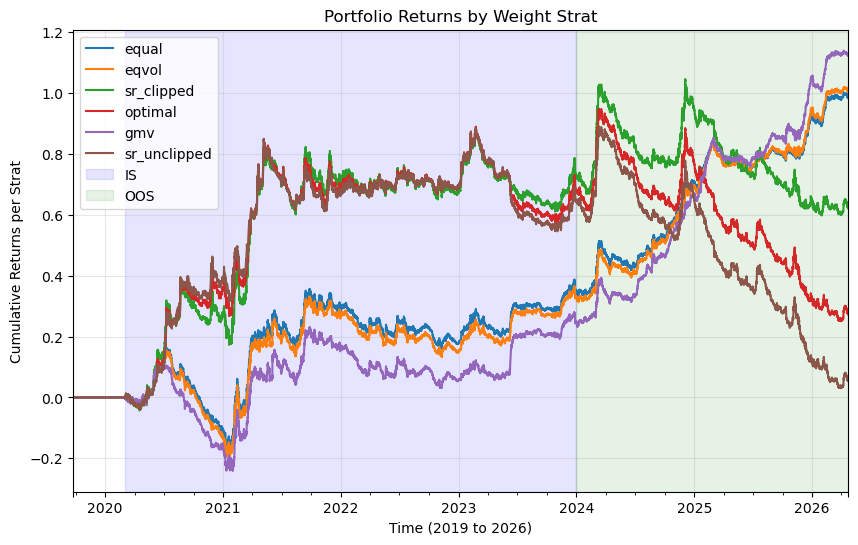

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_ylabel('Cumulative Returns per Strat')
ax.set_xlabel('Time (2019 to 2026)')
for strat, strat_ret in strat_rets.items():
    cumret = strat_ret[0].cumsum().plot(label=strat, ax=ax)
ax.axvspan(IS_START, IS_END, alpha=0.1, color='blue', label='IS')
ax.axvspan(OOS_START, '2026-12-31', alpha=0.1, color='green', label='OOS')
ax.set_title('Portfolio Returns by Weight Strat')
ax.legend()
ax.grid(alpha=0.3)

## Sensitivity

Diagnostic passes, not spec searches. Equal-weight variants only to keep scope bounded.

1. **Drop C.** Equal-weight A+B (1/2 each). Is C actually helping?
2. **Drop B.** Equal-weight A+C (1/2 each). How much does B's IS strength carry the combined?
3. **A-only.** The standalone baseline.
4. **Regime overlay diagnostic.** Apply Signal A's regime gate (BTC 30d annualized vol < 0.6) to the *entire combined* portfolio. Report conditional combined Sharpe. Does the combined improve the way A does in low-vol regimes?

In [29]:
port_variants = {
    'A+B':       port[['A', 'B']] @ pd.Series([1/2, 1/2], index=['A', 'B']),
    'A+C':       port[['A', 'C']] @ pd.Series([1/2, 1/2], index=['A', 'C']),
    'A':         port['A'],
    'A+B gmv':   port[['A', 'B']] @ gmv_weights(sigma_is.loc[['A', 'B'], ['A', 'B']]),
    'A+C gmv':   port[['A', 'C']] @ gmv_weights(sigma_is.loc[['A', 'C'], ['A', 'C']]),
    'A+B eqvol': port[['A', 'B']] @ eqvol_weights(sigma_is.loc[['A', 'B'], ['A', 'B']]),
    'A+C eqvol': port[['A', 'C']] @ eqvol_weights(sigma_is.loc[['A', 'C'], ['A', 'C']]),
}

port_variants_rows = []
for name, rets in port_variants.items():
    for wname, (start, end) in windows.items():
        ns = get_stats(rets.loc[start:end], BARS_PER_YEAR_4H)
        port_variants_rows.append({
            'portfolio': name,
            'window': wname,
            'net_sharpe': ns['sharpe'],
            'net_ret_ann': ns['ret_ann'],
            'net_vol_ann': ns['vol_ann'],
            'net_max_dd': ns['max_dd'],
        })

port_variants_df = pd.DataFrame(port_variants_rows)
port_sharpe_df = port_variants_df.pivot(index='portfolio', columns='window', values='net_sharpe')
port_ret_df = port_variants_df.pivot(index='portfolio', columns='window', values='net_ret_ann')
port_dd_df = port_variants_df.pivot(index='portfolio', columns='window', values='net_max_dd')

print('Net Sharpe by Portfolio Variant & Window\n', port_sharpe_df.round(3))
print('\nAnnualized Return by Portfolio Variant & Window\n', port_ret_df.round(3))
print('\nMax Drawdown by Portfolio Variant & Window\n', port_dd_df.round(3))


Net Sharpe by Portfolio Variant & Window
 window      Full     IS    OOS
portfolio                     
A          1.165 -0.400  4.276
A+B        1.375  0.382  3.542
A+B eqvol  1.410  0.335  3.762
A+B gmv    1.425  0.309  3.868
A+C        1.037  0.164  2.865
A+C eqvol  1.060  0.139  2.981
A+C gmv    1.079  0.116  3.083

Annualized Return by Portfolio Variant & Window
 window      Full     IS    OOS
portfolio                     
A          0.266 -0.099  0.922
A+B        0.189  0.058  0.443
A+B eqvol  0.193  0.051  0.466
A+B gmv    0.195  0.047  0.478
A+C        0.168  0.029  0.431
A+C eqvol  0.171  0.025  0.448
A+C gmv    0.175  0.020  0.464

Max Drawdown by Portfolio Variant & Window
 window      Full     IS    OOS
portfolio                     
A         -0.657 -0.657 -0.222
A+B       -0.294 -0.294 -0.115
A+B eqvol -0.315 -0.315 -0.106
A+B gmv   -0.325 -0.325 -0.102
A+C       -0.479 -0.479 -0.080
A+C eqvol -0.484 -0.484 -0.080
A+C gmv   -0.487 -0.487 -0.080


In [30]:
btc_ret = ret['BTCUSDT']
btc_vol_30d = btc_ret.rolling(180).std() * np.sqrt(BARS_PER_YEAR_4H)
btc_vol_30d_lag = btc_vol_30d.shift(1)
regime_on = btc_vol_30d_lag < 0.60   # match Signal A's actual threshold

combined_equal = port @ pd.Series([1/3, 1/3, 1/3], index=['A', 'B', 'C'])

regime_rows = []
for regime_name, mask in [('Regime ON (low vol)', regime_on),
                          ('Regime OFF (high vol)', ~regime_on)]:
    for wname, (start, end) in windows.items():
        sub = combined_equal.loc[start:end]
        sub_mask = mask.loc[sub.index].fillna(False)
        masked = sub[sub_mask]
        if len(masked) > 30:
            s = get_stats(masked, BARS_PER_YEAR_4H)
            regime_rows.append({
                'regime': regime_name,
                'window': wname,
                'sharpe': s['sharpe'],
                'n_obs': len(masked),
                'frac_of_window': len(masked) / len(sub),
            })

regime_df = pd.DataFrame(regime_rows)
print(regime_df.round(3))


                  regime window  sharpe  n_obs  frac_of_window
0    Regime ON (low vol)     IS  -0.254   4344           0.517
1    Regime ON (low vol)    OOS   2.993   4449           0.880
2    Regime ON (low vol)   Full   1.409   9356           0.649
3  Regime OFF (high vol)     IS   1.224   4062           0.483
4  Regime OFF (high vol)    OOS  -1.357    604           0.120
5  Regime OFF (high vol)   Full   0.939   5061           0.351


## Save Final Portfolio

The vol-weighted schemes (eqvol, GMV) outperform equal-weight, which lines up with the broader finding that volatility governs signals in crypto markets. I commit GMV as the v1 spec and persist eqvol and equal-weight as sensitivity artifacts.

Path: `data/combined_portfolio_v1.pkl`

In [31]:
w_v1 = gmv_weights(sigma_is.loc[['A', 'B'], ['A', 'B']])
combined_v1_net = port[['A', 'B']] @ w_v1
combined_v1_gross = port_gross[['A', 'B']] @ w_v1

sensitivity_artifacts = {
    'eq_A_B_C':    port @ pd.Series([1/3, 1/3, 1/3], index=['A', 'B', 'C']),
    'eqvol_A_B_C': port @ eqvol_weights(sigma_is),
    'gmv_A_B_C':   port @ gmv_weights(sigma_is),
    'eq_A_B':      port[['A', 'B']] @ pd.Series([0.5, 0.5], index=['A', 'B']),
    'gmv_A_B':     combined_v1_net,
    'A_only':      port['A'],
}

artifact = {
    'committed_weights': w_v1.to_dict(),
    'committed_signals': ['A', 'B'],
    'committed_scheme': 'gmv_A_B',
    'combined_net_ret':   combined_v1_net,
    'combined_gross_ret': combined_v1_gross,
    'sensitivity_net_ret': sensitivity_artifacts,
    'sigma_is':  sigma_is,
    'mu_is':     mu_is,
    'config': {
        'is_window': (IS_START, IS_END),
        'oos_window': (OOS_START, None),
        'bars_per_year': BARS_PER_YEAR_4H,
        'cost_bps': DEFAULT_COST_BPS_MARKET,
        'note': (
            'v1 committed: A+B under GMV. '
            'Decision rationale: C failed diversification thesis at portfolio level. '
            'GMV is the strongest mu-free scheme on the pre-registered set. '
            'Pre-registered headline (eq A+B+C, full Sharpe 1.21) retained as sensitivity. '
            'Forward Sharpe estimate 1.0-1.5 with regime-dependence caveat.'
        ),
    }
}

with open(os.path.join(PROJECT_DIR, 'data', 'combined_portfolio_v1.pkl'), 'wb') as f:
    pickle.dump(artifact, f)

print(f"Saved v1 artifact:")
print(f"  Committed signals: {artifact['committed_signals']}")
print(f"  Committed weights: {dict(zip(['A','B'], w_v1.round(4).values))}")
print(f"  combined_net_ret length: {len(combined_v1_net)}")
print(f"  Saved to: data/combined_portfolio_v1.pkl")


Saved v1 artifact:
  Committed signals: ['A', 'B']
  Committed weights: {'A': np.float64(0.5361), 'B': np.float64(0.4639)}
  combined_net_ret length: 14417
  Saved to: data/combined_portfolio_v1.pkl


### BTC factor regression on the committed strategy

Run a factor regression of the committed A+B GMV net returns against BTC across IS / OOS / Full.

In [33]:
btc_ret_panel = ret['BTCUSDT']

ab_gmv_rows = []
for wname, (start, end) in windows.items():
    rets = combined_v1_net.loc[start:end]
    btc = btc_ret_panel.loc[start:end]
    reg = factor_regression(rets, btc, BARS_PER_YEAR_4H)
    n = get_stats(rets, BARS_PER_YEAR_4H)
    ab_gmv_rows.append({
        'window': wname,
        'net_sharpe': n['sharpe'],
        'ret_ann': n['ret_ann'],
        'vol_ann': n['vol_ann'],
        'max_dd': n['max_dd'],
        'beta': reg['beta'],
        'alpha_ann': reg['alpha_ann'],
        'corr': reg['corr'],
        'info_ratio': reg['info_ratio'],
    })

ab_gmv_df = pd.DataFrame(ab_gmv_rows).set_index('window')
print('Committed A+B GMV book vs BTC:')
print(ab_gmv_df.round(4))

Committed A+B GMV book vs BTC:
        net_sharpe  ret_ann  vol_ann  max_dd    beta  alpha_ann    corr  \
window                                                                    
IS          0.3092   0.0467   0.1510 -0.3251  0.0077     0.0417  0.0342   
OOS         3.8679   0.4778   0.1235 -0.1021  0.0020     0.4771  0.0077   
Full        1.4252   0.1947   0.1366 -0.3251  0.0059     0.1918  0.0262   

        info_ratio  
window              
IS          0.2766  
OOS         3.8620  
Full        1.4043  


### Final committed portfolio

Cumulative compounded returns of the committed v1 spec (A+B under GMV) over the full sample, with IS and OOS shaded.

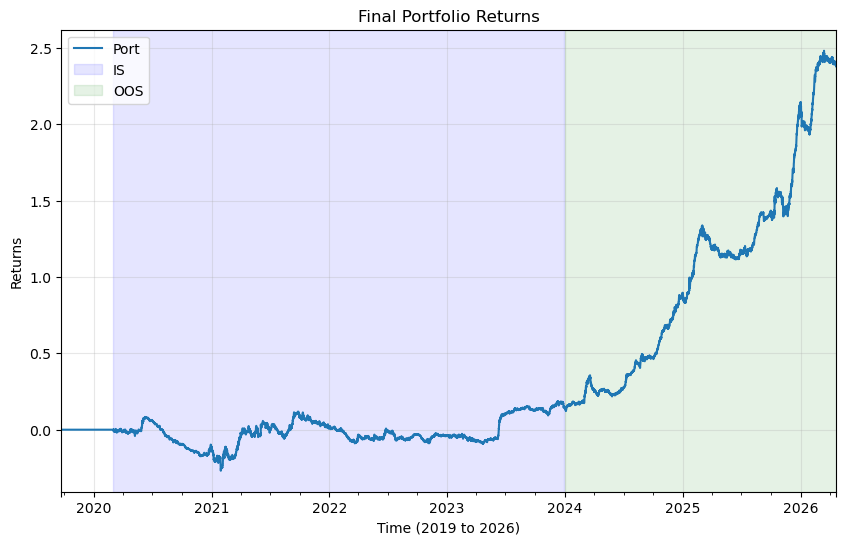

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_ylabel('Returns')
ax.set_xlabel('Time (2019 to 2026)')
cumret = ((1+combined_v1_net).cumprod() - 1).plot(label='Port', ax=ax)
ax.axvspan(IS_START, IS_END, alpha=0.1, color='blue', label='IS')
ax.axvspan(OOS_START, '2026-12-31', alpha=0.1, color='green', label='OOS')
ax.set_title('Final Portfolio Returns')
ax.legend()
ax.grid(alpha=0.3)

## Conclusions

### Headline result

**v1 spec: A+B under GMV weights, IS-estimated covariance.**

| Metric | Full | IS | OOS |
|---|---|---|---|
| Net Sharpe | **1.43** | 0.31 | **3.87** |
| Ann. return (net) | 19.5% | 4.7% | 47.8% |
| Ann. vol | 13.7% | 15.1% | 12.4% |
| Max drawdown | -33% | -33% | -10% |
| Beta to BTC | 0.006 | 0.008 | 0.002 |
| $\alpha$ (annualized) | 19% | 4% | 48% |

Net of 20bps market-execution costs. The strategy is market-neutral ($\beta \approx 0$ in every window), so almost all the return shows up as $\alpha$. Committed weights: $w_A \approx 0.54$, $w_B \approx 0.46$.

### Forward expected Sharpe

**Range: 1.0 to 1.5.** Full-sample (1.43) is the upper estimate. IS-only (0.31) is the lower estimate. The OOS Sharpe of 3.87 is not the forward expectation. OOS only covers about two years and 88% of those bars were low-vol periods, vs 65% across the full sample. The strategy got a favourable mix, not a representative one.

The strategy works in both states. Full-sample Sharpe is 1.41 in low-vol periods and 0.94 in high-vol periods. Both positive. So forward performance does not depend on any one period type continuing. It only varies in size.

### Where the Sharpe comes from

Two roughly equal contributors:

1. **Signal A (volume-confirmed XS reversal, vol-gated, weight ~54%).** Standalone full Sharpe 1.17, gross Sharpe 4.58. Most of the gross Sharpe survives costs because the vol gate turns the signal off in periods where it would otherwise lose.

2. **Signal B (XS momentum on top-20, weight ~46%).** Standalone full Sharpe 0.44, weak on its own. Its value is the -0.36 anti-correlation with A. That hedge raises Sharpe and cuts drawdown in the combined book.

The combined book is not a stronger version of either signal. It is a hedged book. A+B alone has a max drawdown of -29% vs A-alone's -66%, with similar return per unit of risk.

### Weighting and Signal Selection

I committed to six weighting schemes as the candidate set. Three use $\mu$ (sr_weights clipped/unclipped, optimal_weights), three do not (equal-weight, eqvol, GMV). The three $\mu$-based schemes all lost money OOS. Signal A's IS $\mu$ is negative, so $\mu$-based weights down-weight A and over-weight C. That kills the OOS result, since A is the strongest signal once the high-vol period of 2020-2022 ends.

Here's the reasoning behind switching from using all 3 signals to just A and B:

- **Drop C.** corr(C,A) is near zero, so C does not hedge A. corr(C,B) is +0.20 IS, so C and B move together rather than offsetting. C's IS Sharpe (0.59) is below B's (0.79). Adding C raises portfolio vol without cutting risk, so the combined book is worse with C in it.
- **Use GMV.** GMV does not use $\mu$, so it isn't drawn down by Signal A's negative IS mean. It only uses the correlation structure between signals, which is stable across IS and OOS. On 3-signal A+B+C, GMV beats equal-weight on full Sharpe (1.39 vs 1.16). On 2-signal A+B, GMV (1.43) beats equal (1.38). The lift is small but consistent.

The originally pre-registered A+B+C equal-weight (full Sharpe 1.16, OOS 2.43) is kept in the artifact as a sensitivity case alongside the other schemes.

### What would invalidate this result

- **$\Sigma$ stops being stable.** A-B corr is -0.32 IS / -0.43 OOS / -0.36 full. Stable across the sample. If that correlation drifts to zero or flips positive in a future period, GMV no longer hedges and the combined Sharpe falls. Worth tracking on a rolling basis.
- **Cost model is wrong.** 20bps is a market-order assumption. Real slippage on Binance.US thin alts could be higher depending on size traded. The combined net Sharpe would fall. Tighter universe (top-20 by dvol) or limit-order execution (7bps) would be the response if real slippage runs hot.
- **Forward periods are mostly high-vol.** OOS was 88% low-vol. Full sample is 65% low-vol. If forward markets look more like 2020-2022, expected Sharpe falls toward the high-vol full-sample number (~0.94).

### Sharpe Goals

Forward estimate of **1.0 to 1.5**. I do not claim 1.5 with confidence since the full-sample point estimate is 1.43.

### Future Signals to Test and Plans

1. **Forward-test the spec on new held-out data.**
2. **Finish the BTC intraday seasonality signal (Signal D) on 1H data** as a third diversifier.
3. **Limit-order cost scenario (7bps)** to see how much net Sharpe improves under a more realistic execution model.
4. **Rolling $\Sigma$ estimation** as a robustness check on GMV. Does a rolling 1-year window change the result vs a static IS $\Sigma$?
